## Ejercicio 1

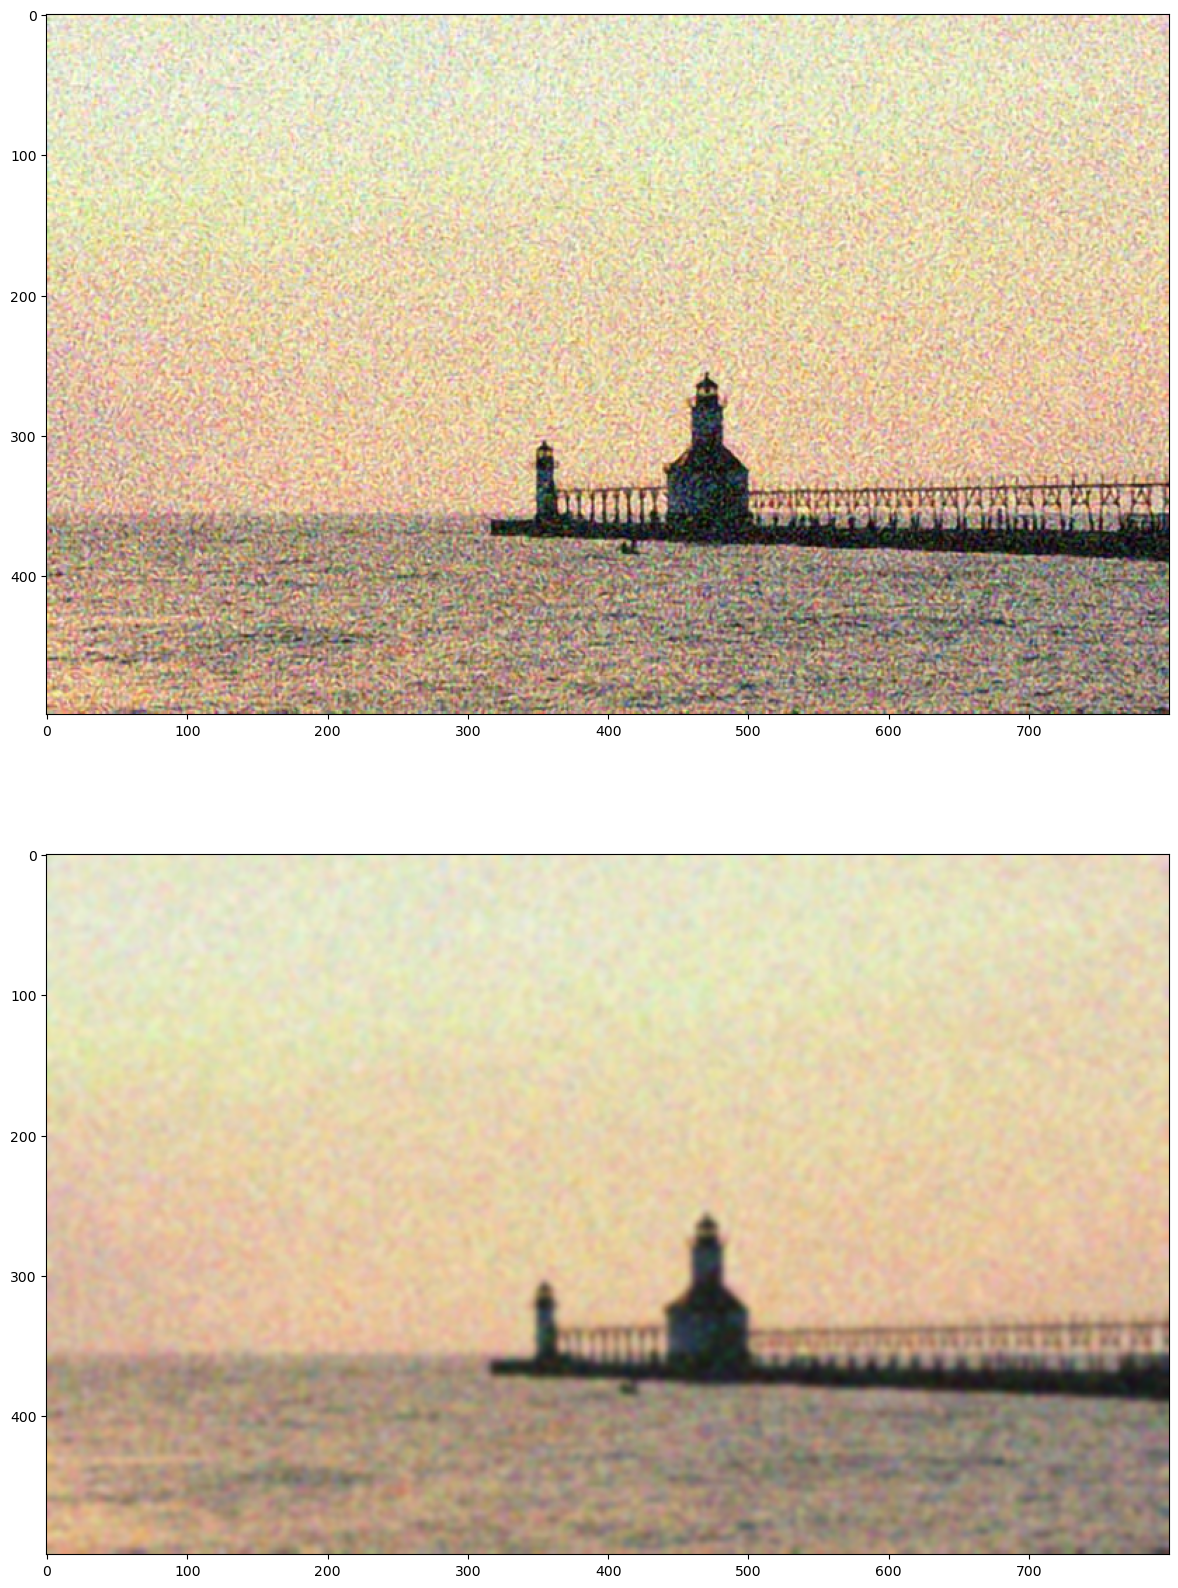

In [38]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

imgo1 = cv2.imread("ruido.jpg")
img1 = cv2.cvtColor(imgo1,cv2.COLOR_BGR2RGB)

maskDiagonal = np.array([
    [1,0,1],
    [0,-1,0],
    [1,0,1]
    ],dtype=np.float32
)/3

final1 = cv2.GaussianBlur(img1,(13,13),0)
fig,axs = plt.subplots(2,1,figsize=(20,20))

axs[0].imshow(img1)
axs[1].imshow(final1)


## Ejercicio 2

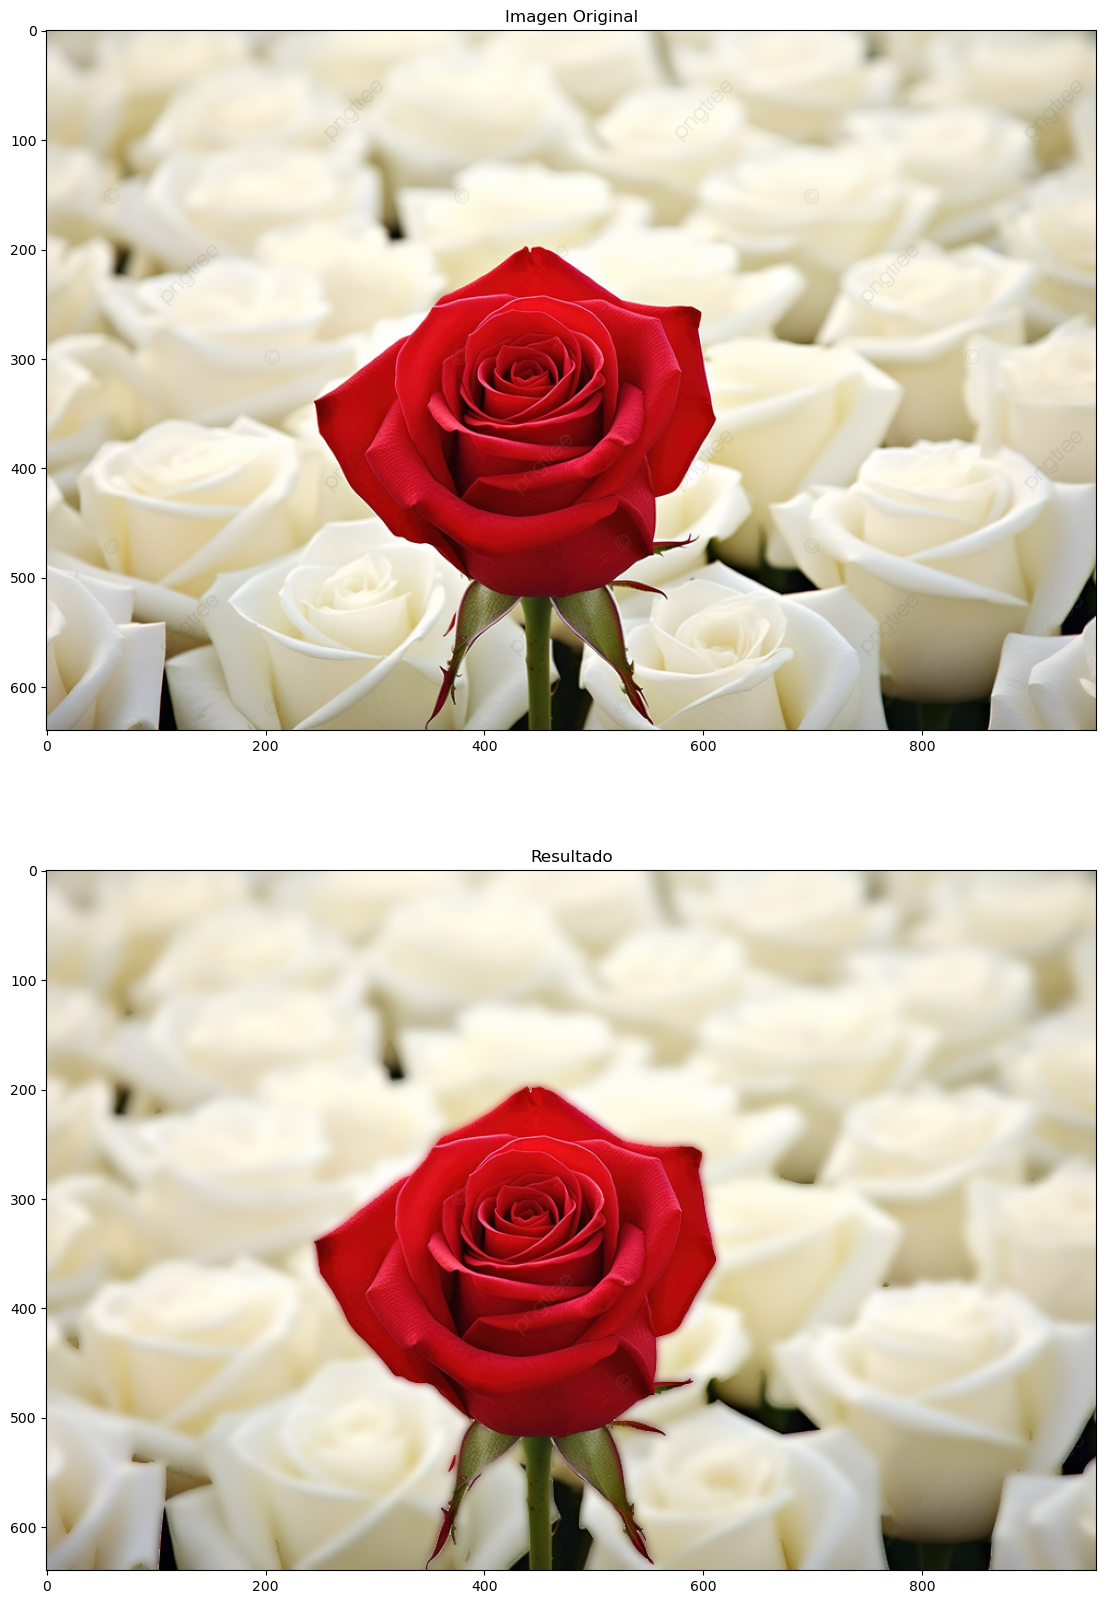

In [109]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def desenfoqueROI(img):
    img1 = np.copy(img)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray,(5,5),0)
    _,binarizado = cv2.threshold(blur,0,255,cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    cant,region = cv2.connectedComponents(binarizado)
    colores = np.random.randint(254,255,size=(cant,3),dtype=np.uint8)
    colores[0] = [0,0,0]
    color_regionb = colores[region]
    mascara = color_regionb
    maskinv = cv2.bitwise_not(mascara)
    desenfoque = cv2.GaussianBlur(img1, (23, 23), 0)
    fondo_desenfocado = cv2.bitwise_and(desenfoque, maskinv)
    circuloClaro = cv2.bitwise_and(img1, mascara)
    resultado = cv2.add(fondo_desenfocado, circuloClaro)
    return resultado

imgo1 = cv2.imread("rosa.png")
img_rgb = cv2.cvtColor(imgo1, cv2.COLOR_BGR2RGB)
final2 = desenfoqueROI(img_rgb)

fig, axs = plt.subplots(2, 1, figsize=(20, 20))
axs[0].imshow(img_rgb)
axs[0].set_title("Imagen Original")
axs[1].imshow(final2)
axs[1].set_title("Resultado")
plt.show()


## Ejercicio 3

Text(0.5, 1.0, 'Conteo: 203')

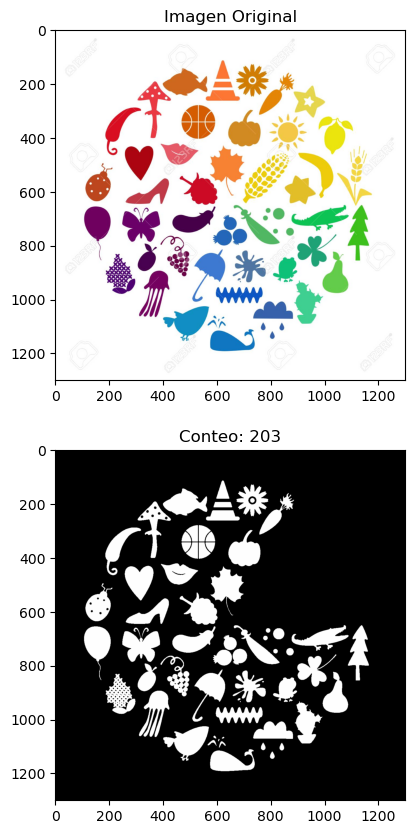

In [85]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def contar(imagen):
    gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    _,binarizar = cv2.threshold(gray, 210,255,cv2.THRESH_BINARY)
    etiquetar = measure.label(binarizar, connectivity=2) 
    num = np.max(etiquetar)
    return num

img = cv2.imread("elementos.jpg")
imgrgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray,(5,5),0)
_,binarizado = cv2.threshold(blur,0,255,cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

#regiones
cant,region = cv2.connectedComponents(binarizado)
colores = np.random.randint(254,255,size=(cant,3),dtype=np.uint8)
colores[0] = [0,0,0]
color_regionb = colores[region]
conteo = contar(img)

figure,axs = plt.subplots(2,1,figsize=(10,10))
axs[0].imshow(imgrgb)
axs[0].set_title("Imagen Original")
axs[1].imshow(color_regionb)
axs[1].set_title(f"Conteo: {conteo}")


## Ejercicio 4

Text(0.5, 1.0, 'Imagen Empañada (Convolucion)')

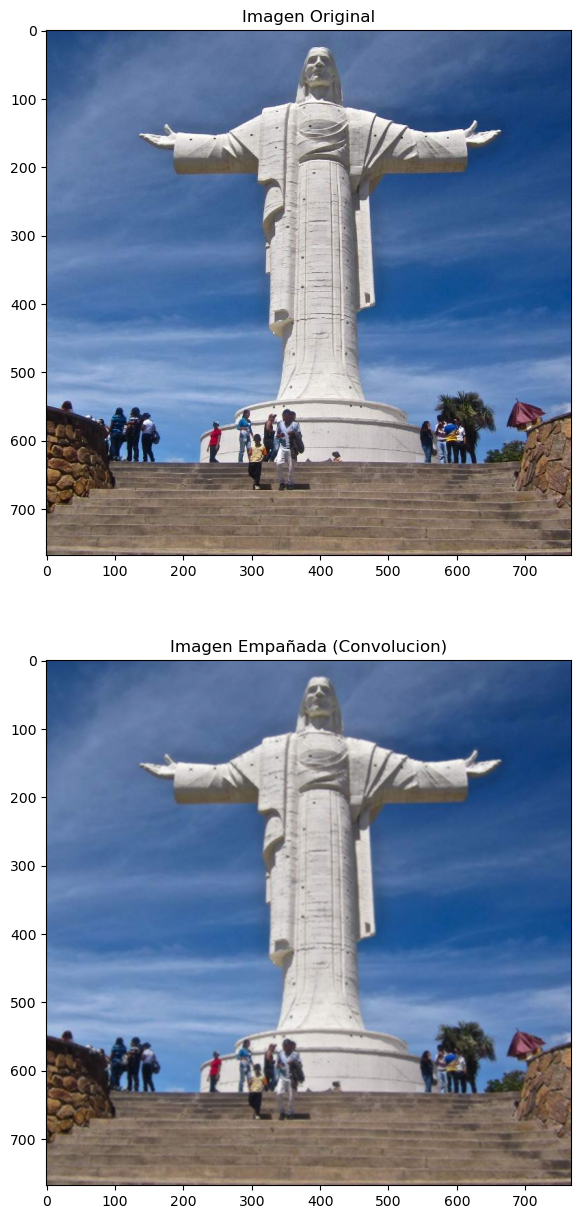

In [108]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imgo = cv2.imread("cristo.jpg")
img = cv2.cvtColor(imgo,cv2.COLOR_BGR2RGB)

mask1 = np.array([[0,-1,0],[1,5,-1],[0,1,0]])/5
# mask1 = np.ones((5,5),np.float32)/(5*5)
mask7 = np.array([[1,-2,1],[-2,5,-2],[1,-2,1]])
mask10 = np.array([[1,2,3,2,1],[2,7,11,7,2],[3,11,17,11,3],[2,7,11,7,2],[1,2,3,1,1]])/(11*11)

final = cv2.filter2D(img, -1, mask1)
final = cv2.filter2D(final, -1, mask7)
final = cv2.filter2D(final, -1, mask10)

fig,axs = plt.subplots(2,1,figsize=(10,15))
axs[0].imshow(img)
axs[0].set_title("Imagen Original")
axs[1].imshow(final)
axs[1].set_title("Imagen Empañada (Convolucion)")